# Eingangssignale: Wellen und Stimmen

Der Ausgangspunkt jeder Audiosignalverarbeitung ist das gemessene Mikrofonsignal. Dieses kann entweder eine Wave-Datei oder die Ausgabe eines Mikrofontreibers sein.
In der Luft sind Audiosignale Änderungen von Druck und Teilchengeschwindigkeit. Diese Änderungen werden von Mikrofonen oder vom menschlichen Ohr aufgenommen.
Bevor die digitale Signalverarbeitung starten kann, wird das Mikrofonsignal $x(t)$ durch den Analog-Digital-Wandler (ADC) von der analogen in die digitale Welt überführt.
Der ADC kann durch drei Parameter beschrieben werden:

1) Übersteuerungspunkt $A$: die maximale analoge Amplitude, die ohne Verzerrung umgewandelt werden kann. Wenn Amplituden oberhalb des Übersteuerungspunkts gemessen werden, tritt Clipping auf. Alle Amplituden von $x(t)$ liegen nach der Quantisierung im Bereich $-A..A$.
2) Abtastrate $r$: die Abtastrate gibt an, wie viele Abtastwerte pro Sekunde gemessen werden. In der Audioverarbeitung sind häufige Abtastraten $r=44100$ Hz (Audio-CD), $r=48000$ Hz (professionelle Audiotechnik), $r=16000$ Hz (Breitband-Audio) oder $r=8000$ Hz (Schmalband-Audio). Der Kehrwert der Abtastrate ist die Abtastdauer $T=\frac{1}{r}$, die dem zeitlichen Abstand zwischen zwei benachbarten Abtastwerten entspricht.
3) Anzahl der Bits $w$: die Quantisierung verwendet eine festgelegte Anzahl von Bits pro Abtastwert. Dadurch sind $2^w$ verschiedene Quantisierungsstufen der Amplituden möglich. Daraus ergibt sich die Quantisierungsstufe $\Delta=\frac{2A}{2^w}$.

Das Produkt aus Abtastrate $r$ und Bitanzahl $w$ ergibt die Datenmenge pro Audiokanal und Sekunde.

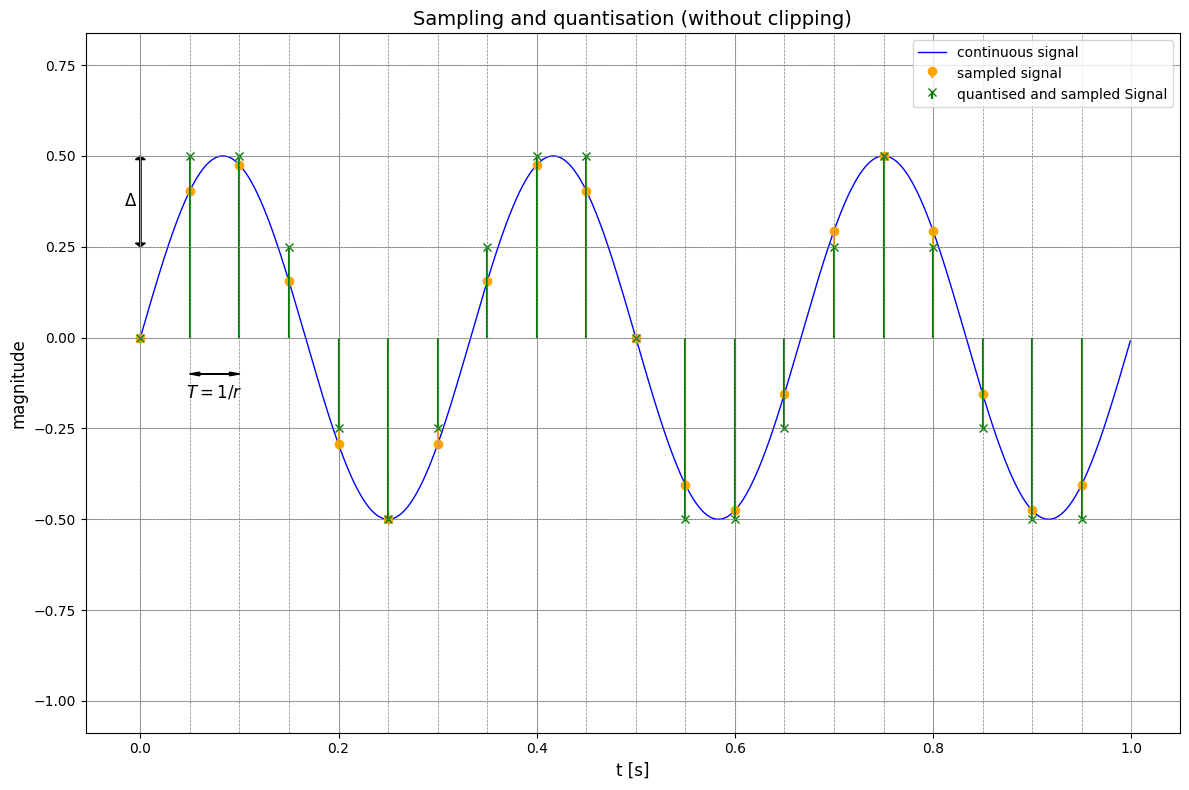

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def CreatePlot(A, fs_cont, t_cont, signal_cont, title="Abtastung und Quantisierung (ohne Clipping)"):
    r = 20  # niedrige Abtastrate zur Visualisierung von Abtastung und Quantisierung
    SamplingFactor = int(fs_cont / r)
    t_sampled = t_cont[::SamplingFactor]
    signal_sampled = signal_cont[::SamplingFactor]

    w = 3
    quantization_levels = 2**w  # Anzahl der Quantisierungsstufen
    delta = (2*A) / quantization_levels
    #signal_quantized = np.round(signal_sampled * (quantization_levels / 2)) / (quantization_levels / 2)
    signal_quantized = np.round(signal_sampled / delta)
    signal_quantized = np.minimum(signal_quantized, quantization_levels // 2 - 1)  # auf maximale Stufe begrenzen
    signal_quantized = np.maximum(signal_quantized, -quantization_levels // 2)  # auf minimale Stufe begrenzen
    signal_quantized = signal_quantized * delta

    plt.figure(figsize=(12, 8))
    plt.plot(t_cont, signal_cont, label="kontinuierliches Signal", color="blue", linewidth=1)
    plt.stem(t_sampled, signal_sampled, linefmt="orange", markerfmt="o", basefmt=" ", label="abgetastetes Signal")
    plt.stem(t_sampled, signal_quantized, linefmt="green", markerfmt="x", basefmt=" ", label="quantisiertes und abgetastetes Signal")

    # alle Quantisierungsintervalle markieren
    for t in t_sampled:
        plt.axvline(x=t, color='gray', linestyle='--', linewidth=0.5)
    value = -A
    while value < A:
        plt.axhline(value, color='gray', linestyle='--', linewidth=0.5)
        value += delta

    # Quantisierungsstufe Δ darstellen
    plt.arrow(0, delta, 0, delta, head_width=0.01, head_length=0.01, linewidth=1, color='k', length_includes_head=True)
    plt.arrow(0, 2*delta, 0, -delta, head_width=0.01, head_length=0.01, linewidth=1, color='k', length_includes_head=True)
    plt.text(-0.01, 1.5*delta, r"$\Delta$", ha="center", va="center", fontsize=12, color="black")
    # Darstellung von Abtastrate und Abtastdauer
    plt.arrow(1/r, -0.1, 1/r, 0, head_width=0.01, head_length=0.01, linewidth=1, color='k', length_includes_head=True)
    plt.arrow(2/r, -0.1, -1/r, 0, head_width=0.01, head_length=0.01, linewidth=1, color='k', length_includes_head=True)
    plt.text(1.5/r, -0.15, r"$T=1/r$", ha="center", va="center", fontsize=12, color="black")

    plt.title(title, fontsize=14)
    plt.xlabel("t [s]", fontsize=12)
    plt.ylabel("Amplitude", fontsize=12)
    plt.legend(fontsize=10)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

A = 1.0  # Übersteuerungspunkt
f = 3  # Frequenz des Sinussignals
fs_cont = 1000  # hohe Abtastrate für kontinuierliches Signal
t_cont = np.linspace(0, 1, fs_cont, endpoint=False)
signal_cont = 0.5*A*np.sin(2 * np.pi * f * t_cont)
CreatePlot(A, fs_cont, t_cont, signal_cont)


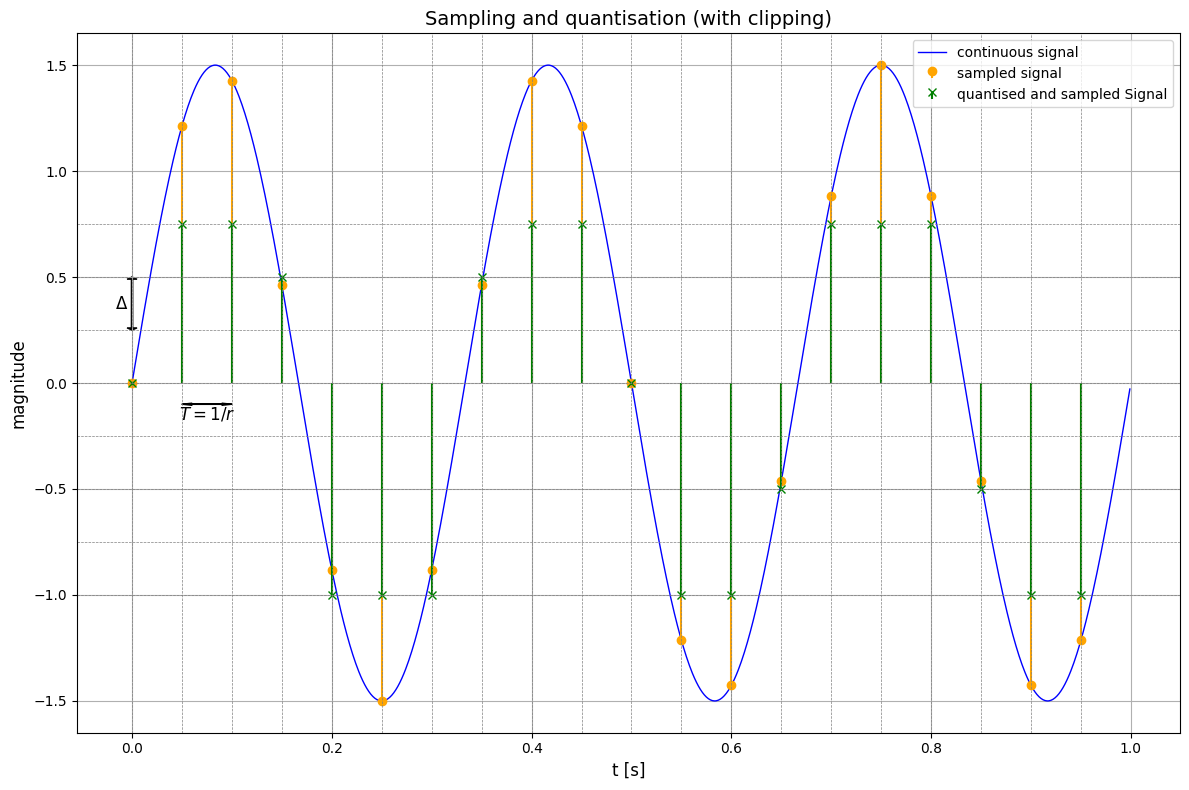

In [ ]:
signal_cont = 1.5*A*np.sin(2 * np.pi * f * t_cont)
CreatePlot(A, fs_cont, t_cont, signal_cont, title="Abtastung und Quantisierung (mit Clipping)")

## Abtasttheorem

Das Abtasttheorem besagt, dass die höchste Frequenz $f_c$ des zeitkontinuierlichen Signals $x(t)$ kleiner oder gleich der halben Abtastrate sein muss:

$f_c \leq \frac{1}{2T} = \frac{r}{2}$

Wird dieses Abtasttheorem verletzt, heißt der entstehende Fehler Alias-Effekt (Aliasing).

Im Folgenden wird das kontinuierliche Signal abgetastet. Danach wird auf Basis des abgetasteten Signals eine Rekonstruktion des kontinuierlichen Signals durchgeführt. Für Audioanwendungen erfolgt die Rekonstruktion durch den idealen Tiefpass als Interpolationsfilter.

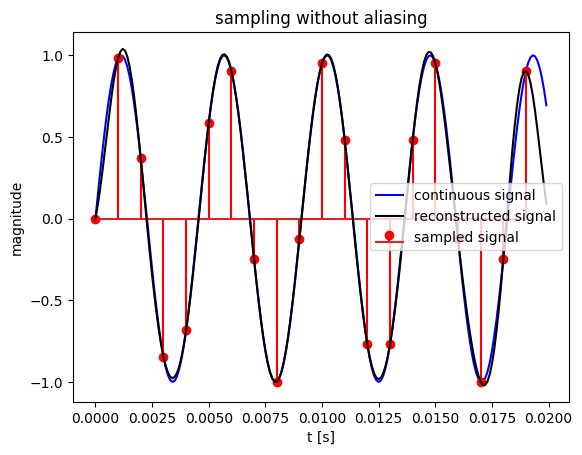

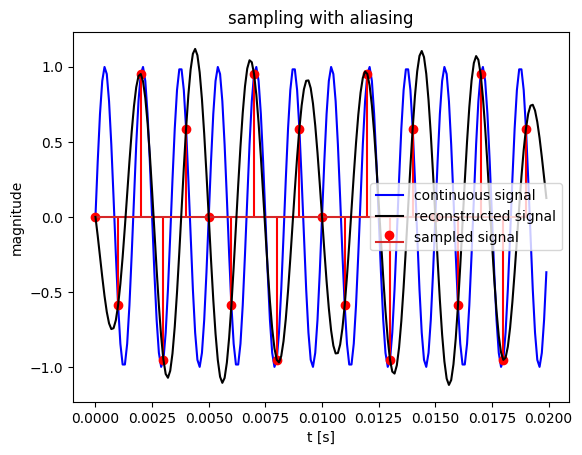

In [ ]:
def TimeContinuousFunction(t, FrequencyInHertz = 220):
    return np.sin(2*np.pi*FrequencyInHertz*t)

def InterpolationFilter(x):
    return np.sinc(x)

def ReconstructedSignal(s_a, t, r, InterpolationFilterFunctionPointer = InterpolationFilter):
    s_tilde = np.zeros(t.shape)
    for n in range(s_a.shape[0]):
        h = InterpolationFilterFunctionPointer(t*r - n)
        s_tilde += s_a[n] * h
    return s_tilde

r = 1000 # Abtastrate in Hertz
UpsamplingFactor = 10
t = np.arange(200)/(UpsamplingFactor*r) # Simulation einer zeitkontinuierlichen Funktion durch zehnmal schnellere Abtastung
s = TimeContinuousFunction(t)

t_a = t[0::UpsamplingFactor]
s_a = TimeContinuousFunction(t_a)

plt.plot(t  , s  , 'b', label='kontinuierliches Signal')
plt.stem(t_a, s_a, 'r', label='abgetastetes Signal')
plt.plot(t, ReconstructedSignal(s_a, t, r), 'k', label='rekonstruiertes Signal')
plt.xlabel('t [s]')
plt.ylabel('Amplitude')
plt.title('Abtastung ohne Aliasing')
plt.legend()
plt.show()

FrequencyInHertz = 600
t = np.arange(200)/(UpsamplingFactor*r)
s = TimeContinuousFunction(t, FrequencyInHertz)
s_a = TimeContinuousFunction(t_a, FrequencyInHertz)
plt.plot(t  , s  , 'b', label='kontinuierliches Signal')
plt.stem(t_a, s_a, 'r', label='abgetastetes Signal')
plt.plot(t, ReconstructedSignal(s_a, t, r), 'k', label='rekonstruiertes Signal')
plt.xlabel('t [s]')
plt.ylabel('Amplitude')
plt.title('Abtastung mit Aliasing')
plt.legend()
plt.show()

## Herunterabtastung
Das Abtasttheorem besagt, dass die folgende Bedingung erfüllt sein muss, wenn Aliasing vermieden werden soll:

$f_c \leq \frac{1}{2T}$

Im Folgenden nehmen wir an, dass die höchste Frequenz $f_c$ eines Signals $x(n)$ deutlich kleiner als die halbe Abtastrate ist:

$f_c \ll \frac{1}{2T}$ 

In diesem Fall ist es möglich, die Abtastrate $r=\frac{1}{T}$ um den Faktor $N$ zu reduzieren:

$N\cdot f_c \leq \frac{1}{2T}$

$\rightarrow N\leq \frac{1}{2Tf_c}=\frac{r}{2f_c}$

Diese Verringerung der Abtastrate wird Herunterabtastung genannt. Wenn $N$ eine ganze Zahl ist, ist die Herunterabtastung ein sehr einfacher Algorithmus:

$x_\text{downsampled}(n)=x\left(N\cdot n\right)$

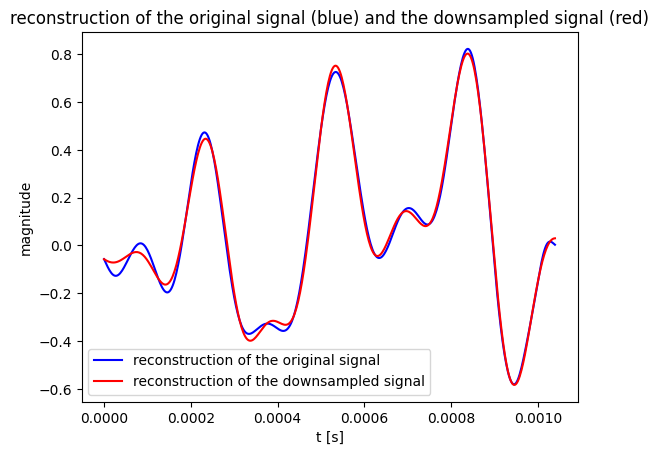

SNR =  24.20135762912092  dB


In [ ]:
r = 48000
x = np.random.randn(50)
fc = 8000
t = np.arange(x.shape[0]) / r
y = np.zeros(x.shape)
for n in range(x.shape[0]):    
    y += x[n] * np.sinc(2*fc*(t - n/r)) * 2 * fc / r

N = 10
t = np.arange(y.shape[0] * N) / (r*N)
z1 = ReconstructedSignal(y, t, r)
DownSamplingFactor = r // (2*fc)

y_Downsampled = y[0::DownSamplingFactor]
z2 = ReconstructedSignal(y_Downsampled, t, r / DownSamplingFactor)
plt.plot(t, z1, 'b', label='Rekonstruktion des Originalsignals')
plt.plot(t, z2, 'r', label='Rekonstruktion des herunterabgetasteten Signals')
plt.title('Rekonstruktion des Originalsignals (blau) und des herunterabgetasteten Signals (rot)')
plt.legend()
plt.xlabel('t [s]')
plt.ylabel('Amplitude')
plt.show()
SNR = 10*np.log10(np.sum(z1**2) / np.sum((z1-z2)**2))
print('SNR = ', SNR, ' dB')

## Logarithmischer Pegel

Im Folgenden werden zwei logarithmische Pegel eingeführt: dB SPL der analogen Welt mit Bezug auf den physikalischen Schalldruck und dB FS der digitalen Welt mit Bezug auf den Übersteuerungspunkt.

### dB-Schalldruckpegel

Das menschliche Ohr kann einen großen Schalldruckbereich verarbeiten. Deshalb wird der Schallpegel üblicherweise als logarithmischer Wert angegeben, z. B. [dB](../Basics/Decibel.ipynb) SPL (Sound Pressure Level):

$L=20\log_{10}\frac{p_\text{eff}}{20\mu\text{Pa}}$ dB SPL

wobei $p_\text{eff}$ dem [RMS](../Basics/RootMeanSquare.ipynb) des Schalldrucks entspricht.
$0$ dB SPL entsprechen einem sehr ruhigen Schlafzimmer, in dem praktisch nichts hörbar ist. $140$ dB SPL entsprechen einem startenden Jet.

### dB Full Scale
dB FS ist auf die maximal mögliche Amplitude eines digitalen Signals normiert. Angenommen, die maximal mögliche Amplitude ist $A$ (gewöhnlich entspricht $A$ dem Übersteuerungspunkt im digitalen Bereich). Ein Sinus mit der Amplitude $A$ hat einen [RMS](../Basics/RootMeanSquare.ipynb) von $\frac{A}{\sqrt{2}}$ und eine [Leistung](../Basics/Power.ipynb) von $P=\frac{A^2}{2}$. Dieser Sinus ist als $0$ dB FS definiert. Ein beliebiges Signal $x(n)$ mit einer Leistung von

$P=\frac{1}{N}\sum_{n=0}^{N-1}x^2(n)$

hat einen [Pegel](../Basics/Decibel.ipynb) von

$L=10\log_{10}\frac{P}{\frac{A^2}{2}}\text{ dB FS}=10\log_{10}\frac{2\cdot P}{A^2}\text{ dB FS}$

Die digitale Ausgabe eines AD-Wandlers wird üblicherweise auf eine maximal mögliche Amplitude von $A=1$ normiert.

### Kalibrierung

Die Kalibrierung kann durch die Messung von dB SPL im physikalischen Bereich und dB FS im digitalen Bereich desselben Signals erfolgen. Die Kalibrierung kann durch den Parameter $a$ beschrieben werden:

$L_\text{dB FS} = a + L_\text{dB SPL}$

Beispiel: Das Smartphone des Dozenten hat einen Kalibrierfaktor von $a\approx115$ dB (gemessen im Januar 2023).

## Quantisierungsrauschen

Digitale Werte werden aufgrund der Quantisierung der Abtastwerte mit einer bestimmten Auflösung gespeichert. Diese Quantisierung entspricht auf der untersten Ebene einer Rundung kontinuierlicher Werte auf diskrete Amplituden mit einer Auflösung von $w$ Bits. Diese Rundung kann als zusätzliches Rauschen in der Aufnahme interpretiert werden, wenn drei Bedingungen erfüllt sind:

1) Das Signal hat eine Leistung, die deutlich höher ist als die Leistung des Quantisierungsrauschens.
2) Die Signalfrequenz ist hoch genug, sodass benachbarte Amplituden statistisch unabhängiges Quantisierungsrauschen haben, und
3) das Signal ist nicht periodisch mit einer Periodendauer $T_0=\frac{n}{r}$, wobei $n$ eine ganze Zahl ist.

- Für Bedingung 1) sollte die Empfindlichkeit des Sensors hoch genug sein, sodass das Signal mit einem sinnvollen Pegel in dB FS aufgenommen wird.
- Bedingung 2) ist für Audio meist kein Problem, da Frequenzen unter etwa $16$ Hz für Menschen nicht hörbar sind. Diese sehr niedrigen Frequenzen können daher ohne Informationsverlust für Menschen herausgefiltert werden.
- Bedingung 3) ist nur bei künstlichen Testsignalen ein Problem (z. B. ein 1-kHz-Signal). In normalen Aufnahmesituationen hat das Eingangssignal ein breites Frequenzspektrum.

Wenn die Bedingungen 1) bis 3) erfüllt sind, kann das Quantisierungsrauschen für $w$ Bits als weißes Rauschen mit der Leistung

$P_E=\frac{\Delta^2}{12}$

mit

$\Delta=\frac{2A}{2^w}$

interpretiert werden.

## Dithering
Wenn mindestens eine der drei Bedingungen für die Weißrauschannahme des Quantisierungsrauschens nicht erfüllt ist, sollte auf das digitale Signal nach der Analog-Digital-Wandlung Dithering angewendet werden:

Dithering fügt dem Signal Zufallsrauschen auf dem Niveau des niederwertigsten Bits hinzu.
Dadurch wird das Quantisierungsrauschen wieder weiß.

In [ ]:
r = 48000
w = 8
factor = 2**(w-1) # ein Bit ist für das Vorzeichen reserviert
f = 1000
t = np.arange(r) / r
x = np.sin(2*np.pi*f*t) # periodisches Signal mit einer Periodendauer von 1 ms, verletzt Bedingung 3)
x_quantised =np.round(x*factor) / factor
DitheringNoise = (np.random.rand(x.shape[0]) - 0.5) / factor # Dithering-Rauschen auf dem niederwertigsten Bit
y = x_quantised + DitheringNoise
y_quantised = np.round(y*factor) / factor
ErrorByDithering = np.sum((x_quantised - y_quantised)**2)
print('Fehler durch Dithering: ', ErrorByDithering)

Error due to dithering:  0.0


## Programmieraufgabe:

Ergänze den fehlenden Code in den folgenden Prozeduren:

1) EvaluatePowerOfSignal

2) EvaluateSNROfQuantization

3) EvaluateSNR

4) EvaluatedBFullScale

5) EvaluatedBSoundPressureLevel

In [ ]:
import unittest



def EvaluatePowerOfSignal(x):
    x = np.asarray(x)  # sicherstellen, dass x ein NumPy-Array ist
    P_S = np.mean(x**2)  # mittlere Leistung berechnen
    return P_S



def EvaluateSNROfQuantization(w):
    A = 1.0  # Übersteuerungspunkt
    x = np.random.rand(10000) * 2 * A - A  # gleichverteiltes Testsignal im Bereich [-A, A]
    P_S = EvaluatePowerOfSignal(x)  # Signal-Leistung
    delta = (2*A)/(2**w)  # Quantisierungsintervall
    P_N = (delta**2)/12  # Leistung des Quantisierungsrauschens
    SNR = 10*np.log10(P_S / P_N)  # SNR in dB
    return SNR



def EvaluateSNR(x, y):
    x = np.asarray(x)  # sicherstellen, dass x ein NumPy-Array ist
    y = np.asarray(y)  # sicherstellen, dass y ein NumPy-Array ist
    error = x - y  # Fehler berechnen
    P_S = EvaluatePowerOfSignal(x)  # Signal-Leistung
    P_N = EvaluatePowerOfSignal(error)  # Fehler-Leistung
    SNR = 10*np.log10(P_S / P_N)  # SNR in dB
    return SNR



def EvaluatedBFullScale(A, x):
    x = np.asarray(x)  # sicherstellen, dass x ein NumPy-Array ist
    P = EvaluatePowerOfSignal(x)  # Signal-Leistung
    L_dBFS = 10 * np.log10(2 * P / (A**2))  # Pegel in dB FS
    return L_dBFS



def EvaluatedBSoundPressureLevel(x_inPascal):
    x_inPascal = np.asarray(x_inPascal)  # sicherstellen, dass x ein NumPy-Array ist
    p_eff = np.sqrt(EvaluatePowerOfSignal(x_inPascal))  # Effektivwert (RMS)
    L_SPL = 20 * np.log10(p_eff / (20e-6))  # Schalldruckpegel in dB SPL
    return L_SPL



class TestProgrammingExercise(unittest.TestCase):

    def test_SNRMonotonicallyIncreasing(self):
        w1 = np.random.randint(20)
        w2 = w1 + 1
        self.assertGreater(EvaluateSNROfQuantization(w2), EvaluateSNROfQuantization(w1))
    
    def test_SNRSlope(self):
        for w in range(16):
            self.assertAlmostEqual(EvaluateSNROfQuantization(w), w*6, delta = 0.5)
            
    def test_EvaluatedBFullScale(self):
        A = np.random.rand(1)
        x = A*np.sin(2*np.pi*440*np.arange(10000)/16000)
        self.assertAlmostEqual(EvaluatedBFullScale(A, x), 0.0, delta = 0.5)
        self.assertAlmostEqual(EvaluatedBFullScale(A, x/np.sqrt(2)), -3.0, delta = 0.5)
        
    def test_EvaluatedBSoundPressureLevel(self):
        a = np.random.rand(1)
        x_inPascal = a*np.sin(2*np.pi*440*np.arange(10000)/16000)
        self.assertAlmostEqual(EvaluatedBSoundPressureLevel(x_inPascal), 20*np.log10(a) + 90.969, delta = 0.5)
        
    def test_EvaluatePowerOfSignalSinus(self):
        A = np.random.rand(1)
        x = A*np.sin(2*np.pi*440*np.arange(10000)/16000)
        self.assertAlmostEqual(EvaluatePowerOfSignal(x), A**2/2, delta = 0.01)

    def test_EvaluatePowerOfSignalUniformNoise(self):
        A = np.random.rand(1)
        x = 2*A*np.random.rand(10000)-A
        self.assertAlmostEqual(EvaluatePowerOfSignal(x), (2*A)**2/12, delta = 0.01)
        
    def test_EvaluatePowerOfSignalGaussianNoise(self):
        s = np.random.rand(1)
        x = s*np.random.randn(10000)
        self.assertAlmostEqual(EvaluatePowerOfSignal(x), s**2, delta = 0.1)
        
    def test_EvaluateSNRErrorEqualSignal(self):
        x = np.random.randn(10000)
        e = np.random.randn(10000)
        y = x + e
        self.assertAlmostEqual(EvaluateSNR(x, y), 0.0, delta = 0.5)
        
    def test_EvaluateSNRSmallError(self):
        factor = 1e-3
        x = np.random.randn(10000)
        e = np.random.randn(10000) * factor
        y = x + e
        self.assertAlmostEqual(EvaluateSNR(x, y), -20*np.log10(factor), delta = 3.0)

# https://stackoverflow.com/questions/40172281/unit-tests-for-functions-in-a-jupyter-notebook
unittest.main(argv=[''], verbosity=2, exit=False)

test_EvaluatePowerOfSignalGaussianNoise (__main__.TestProgrammingExercise.test_EvaluatePowerOfSignalGaussianNoise) ... ok
test_EvaluatePowerOfSignalSinus (__main__.TestProgrammingExercise.test_EvaluatePowerOfSignalSinus) ... ok
test_EvaluatePowerOfSignalUniformNoise (__main__.TestProgrammingExercise.test_EvaluatePowerOfSignalUniformNoise) ... ok
test_EvaluateSNRErrorEqualSignal (__main__.TestProgrammingExercise.test_EvaluateSNRErrorEqualSignal) ... ok
test_EvaluateSNRSmallError (__main__.TestProgrammingExercise.test_EvaluateSNRSmallError) ... ok
test_EvaluatedBFullScale (__main__.TestProgrammingExercise.test_EvaluatedBFullScale) ... ok
test_EvaluatedBSoundPressureLevel (__main__.TestProgrammingExercise.test_EvaluatedBSoundPressureLevel) ... ok
test_SNRMonotonicallyIncreasing (__main__.TestProgrammingExercise.test_SNRMonotonicallyIncreasing) ... ok
test_SNRSlope (__main__.TestProgrammingExercise.test_SNRSlope) ... ok

---------------------------------------------------------------------

test_EvaluatePowerOfSignalGaussianNoise (__main__.TestProgrammingExercise.test_EvaluatePowerOfSignalGaussianNoise) ... ok
test_EvaluatePowerOfSignalSinus (__main__.TestProgrammingExercise.test_EvaluatePowerOfSignalSinus) ... ok
test_EvaluatePowerOfSignalUniformNoise (__main__.TestProgrammingExercise.test_EvaluatePowerOfSignalUniformNoise) ... ok
test_EvaluateSNRErrorEqualSignal (__main__.TestProgrammingExercise.test_EvaluateSNRErrorEqualSignal) ... ok
test_EvaluateSNRSmallError (__main__.TestProgrammingExercise.test_EvaluateSNRSmallError) ... ok
test_EvaluatedBFullScale (__main__.TestProgrammingExercise.test_EvaluatedBFullScale) ... ok
test_EvaluatedBSoundPressureLevel (__main__.TestProgrammingExercise.test_EvaluatedBSoundPressureLevel) ... ok
test_SNRMonotonicallyIncreasing (__main__.TestProgrammingExercise.test_SNRMonotonicallyIncreasing) ... ok
test_SNRSlope (__main__.TestProgrammingExercise.test_SNRSlope) ... ok

---------------------------------------------------------------------

## Prüfungsvorbereitung

1) Ein Quantisierer mit $w=16$ Bit wird verwendet. Gib die Datenmenge für 70 Minuten Aufnahme auf einer Audio-CD an. Hinweis: Audio-CDs werden im Stereo-Modus aufgenommen.

2) Bestimme den Pegel in dB SPL eines Sinus mit einer Amplitude von $0.1$ Pa. Dieser Sinus wird zu einem digitalen Signal $x(n)=0.25\cdot\sin\left(2\pi f\frac{n}{r}\right)$ digitalisiert. Die maximal mögliche Amplitude dieses AD-Wandlers ist $A=1.0$. Bestimme den zugehörigen Pegel in dB FS und den Kalibrierfaktor $a$.

3) Bestimme die SNR für ein Signal mit $-12$ dB FS bei Quantisierungsrauschen für $w=16$ Bit. $A=1.0$ gilt weiterhin.

4) Gegeben ist ein Signal $x(t)=a\cdot\cos\left(2\pi ft\right)$ mit $f=2$ kHz. $x(t)$ hat einen Pegel von $75$ dB SPL. Bestimme den Parameter $a$. Ist es möglich, das Vorzeichen von $a$ anhand der gegebenen Informationen zu bestimmen? Bestimme den Pegel in dB SPL, wenn die Frequenz verdoppelt wird.

5) Welche Art von Funktion $y=f(x)$ ergibt bei einer logarithmischen x-Achse, bei einer logarithmischen y-Achse und bei einem doppelt-logarithmischen Diagramm jeweils einen linearen Verlauf?

6) Ein Signal hat einen Kalibrierfaktor von $a=-120$ dB. Bestimme den Übersteuerungspunkt in dB SPL. Nimm an, dass das Signal ein Sinus ist.

7) Bestimme den Pegel in dB FS des Quantisierungsrauschens für $w=16$ Bits.

8) Gib die mathematische Beschreibung eines digitalen Signals an, das dem höchstmöglichen Pegel in dB FS entspricht. Wie groß ist der zugehörige Pegel in dB FS?

9) Ein zeitkontinuierliches Signal $x(t)=\cos\left(7\cdot t\right)^2$ wird mit $r=10$ Hz abgetastet. Bestimme die ersten fünf Abtastwerte.

10) Ein zeitdiskretes Signal mit $r=32$ kHz wird durch einen Tiefpass mit Grenzfrequenz $f_c=3400$ Hz gefiltert. Wie groß ist die kleinste notwendige Abtastfrequenz nach dem Tiefpass? Wie groß ist der maximal zulässige ganzzahlige Downsampling-Faktor? Entspricht das Signal nach dem Tiefpass Breitband- oder Schmalband-Sprache?

11) Ein Mikrofonsignal $y(n)$ wird mit $r=48$ kHz aufgenommen. Danach wird $y(n)$ durch einen Bandpass $h(n)$ mit Grenzfrequenzen $f_1=100$ Hz und $f_2=7000$ Hz gefiltert: $z(n)=h(n)*y(n)$. Hat $z(n)$ einen DC-Anteil? Ist menschliche Sprache in $z(n)$ verständlich? Was sind die höchsten Frequenzen in $y(n)$ und $z(n)$?

12) Ein Signal $x(t)=\cos(500\cdot t)$ wird mit $r=200$ Hz abgetastet. Führt diese Abtastung zu Aliasing? 

## Lösungen zu den Übungsfragen

1) **Datenmenge für 70 Minuten Audio-CD (Stereo, 16 Bit):**  
$70\,\text{min} \times 60\,\text{s/min} \times 44100\,\text{Hz} \times 16\,\text{Bit} \times 2\,\text{Kanäle} = 5\,929\,920\,000\,\text{Bit} = 741.24\,\text{MB}$

2) **dB SPL eines Sinus mit 0.1 Pa:**  
$L_\text{SPL} = 20\log_{10}(0.1/20\mu\text{Pa}) \approx 94\,\text{dB SPL}$  
**dB FS für $x(n)=0.25\sin(\ldots)$, $A=1.0$:**  
$L_\text{dBFS} = 10\log_{10}(2 \cdot (0.25^2/2)/1^2) = -12\,\text{dB FS}$  
**Kalibrierfaktor:**  
$a = L_\text{dBFS} - L_\text{SPL} = -12 - 94 = -106\,\text{dB}$

3) **SNR für $-12$ dB FS, $w=16$:**  
$SNR_Q = 6 \cdot w = 96\,\text{dB}$  
$SNR_\text{gesamt} = -12\,\text{dB FS} - L_\text{Q,FS}$  
$L_\text{Q,FS} = -96\,\text{dB FS}$  
$\Rightarrow SNR = 84\,\text{dB}$

4) **$a$ für $75$ dB SPL:**  
$a = 20\mu\text{Pa} \cdot 10^{75/20} \approx 112.2\,\text{Pa}$  
**Vorzeichen:** Nicht bestimmbar (nur Betrag).  
**Frequenz verdoppelt:** Pegel bleibt gleich (Amplitude bestimmt Pegel, nicht Frequenz).

5) **Funktionen für lineare Plots:**  
    - log-x: $y = a \log(x) + b$  
    - log-y: $y = b \cdot x^a$  
    - doppelt-log: $y = c \cdot x^a$ (Potenzfunktion)

6) **Übersteuerungspunkt bei $a=-120$ dB:**  
$L_\text{dBFS} = a + L_\text{SPL}$, für $L_\text{dBFS}=0$  
$\Rightarrow L_\text{SPL} = 120\,\text{dB SPL}$

7) **Quantisierungsrauschen $w=16$:**  
$L_\text{Q,FS} = -6.02 \cdot w = -96.3\,\text{dB FS}$

8) **Maximaler dB FS:**  
$x(n) = A \cdot \sin(\ldots)$, $L_\text{dBFS} = 0\,\text{dB FS}$

9) **Erste 5 Samples $x(t)=\cos^2(7t)$, $r=10$ Hz:**  
$t_n = n/10$, $x(n) = \cos^2(7 \cdot n/10)$ für $n=0..4$

10) **Nach Tiefpass $f_c=3400$ Hz:**  
$2f_c = 6800$ Hz, also $r_\text{min}=6800$ Hz  
$N_\text{max} = \lfloor 32000/6800 \rfloor = 4$  
**Breitband oder Schmalband:** Breitband (Grenze: 3400 Hz)

11) **Bandpass $100$ Hz bis $7000$ Hz:**  
    - $z(n)$ hat keine DC-Komponente  
    - Sprache verständlich (Stimmfrequenzen enthalten)  
    - $y(n)$: bis 24 kHz, $z(n)$: bis 7 kHz

12) **Alias bei $x(t)=\cos(500t)$, $r=200$ Hz:**  
$500/(2\pi) \approx 79.6$ Hz, $r/2=100$ Hz, also kein Alias, da $f<r/2$.


## Zusammenfassung
Nach der Bearbeitung dieses Jupyter-Notebooks solltest du die folgenden Themen erklären können:

- In welchen Fällen ist der Übersteuerungspunkt $A$ für deine Messung relevant?
- In welchem Fall ist die Anzahl der Bits $w$ für deine Messung relevant?
- In welchem Fall ist die Abtastrate $r$ für deine Messung relevant?
- Was ist das Abtasttheorem?
- Was ist Aliasing?
- Was ist der Unterschied zwischen dB SPL und dB FS?
- Wann möchtest du Dithering einsetzen?
- Wie beeinflusst das Quantisierungsrauschen deine Messung?

## Antworten zu den wichtigsten Themen

- **Übersteuerungspunkt $A$:**
  Relevant, wenn du wissen willst, ab welcher Amplitude dein System verzerrt (Clipping). Alle Messwerte müssen im Bereich $-A$ bis $A$ liegen, sonst gehen Informationen verloren.

- **Anzahl der Bits $w$:**
  Bestimmt die Auflösung der Quantisierung. Je mehr Bits, desto feiner die Abstufung und desto geringer das Quantisierungsrauschen.

- **Abtastrate $r$:**
  Gibt an, wie viele Werte pro Sekunde aufgenommen werden. Sie muss mindestens doppelt so hoch wie die höchste Signalfrequenz sein (siehe Abtasttheorem), um Informationsverlust (Aliasing) zu vermeiden.

- **Abtasttheorem:**
  Ein Signal kann nur dann fehlerfrei rekonstruiert werden, wenn die Abtastrate mindestens doppelt so hoch wie die höchste vorkommende Frequenz ist: $f_c \leq r/2$.

- **Aliasing:**
  Tritt auf, wenn die Abtastrate zu niedrig ist. Höhere Frequenzen erscheinen dann als niedrigere Frequenzen im abgetasteten Signal und verfälschen das Ergebnis.

- **Unterschied dB SPL und dB FS:**
  - dB SPL (Schalldruckpegel): Bezieht sich auf den physikalischen Schalldruck (Vergleich zu 20 µPa, der Hörschwelle).
  - dB FS (Vollaussteuerung): Bezieht sich auf den maximal möglichen Wert im digitalen System (0 dB FS = maximaler Wert).

- **Wann Dithering?**
  Wenn die Bedingungen für weißes Quantisierungsrauschen nicht erfüllt sind (z. B. bei sehr leisen oder periodischen Signalen), wird Dithering eingesetzt, um das Rauschen zu entkoppeln und hörbare Artefakte zu vermeiden.

- **Einfluss des Quantisierungsrauschens:**
  Quantisierungsrauschen ist ein unvermeidlicher Fehler durch die Digitalisierung. Es kann als weißes Rauschen modelliert werden, solange das Signal ausreichend groß und nicht zu regelmäßig ist. Je mehr Bits, desto geringer das Rauschen und desto besser die Signalqualität.